In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Работа с данными

1. Загружаем данные;
2. Смотрим как они выглядят;
3. Проверяем нет ли пропусков в данных;
4. Смотрим тип данных каждого из столбцов.

In [9]:
train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Hackatons/Я пофессионал/Полуфинал/Training_wells.csv')
test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Hackatons/Я пофессионал/Полуфинал/Empty_part.csv')
train.shape, test.shape

((138, 4), (1242, 3))

In [10]:
train.head(10)

,Well,X,Y,NTG
0,201-907,201,907,0.2006
1,201-914,201,914,0.3624
2,201-924,201,924,0.4381
3,202-922,202,922,0.4289
4,202-925,202,925,0.4021
5,203-902,203,902,0.2628
6,203-906,203,906,0.2517
7,203-929,203,929,0.3452
8,204-904,204,904,0.2092
9,204-907,204,907,0.1974


In [11]:
print('Train NaN:')
print(train.isna().any(), '\n')
print('Test NaN:')
print(test.isna().any())

Train NaN:
Well    False
X       False
Y       False
NTG     False
dtype: bool 

Test NaN:
Well    False
X       False
Y       False
dtype: bool


In [12]:
train.dtypes

Well     object
X         int64
Y         int64
NTG     float64
dtype: object

Есть сомнения, что столбец "Well" является значащим в наших данных. Если он повторяет координаты X и Y, то тогда в матрице появляется линейная зависимость, которая мешает строить модели машинного обучения. Проверим:

In [13]:
is_equal = True

for i, row in train.iterrows():
    well_x, well_y = row['Well'].split('-')
    well_x, well_y = int(well_x), int(well_y)
    if well_x != row['X'] or well_y != row['Y']:
        print('Not equal in train index:', i)
        is_equal = False

for i, row in test.iterrows():
    well_x, well_y = row['Well'].split('-')
    well_x, well_y = int(well_x), int(well_y)
    if well_x != row['X'] or well_y != row['Y']:
        print('Not equal in test index:', i)
        is_equal = False

if is_equal:
    print('Well equal to X and Y')
else:
    print('Well doesnt equal to X and Y')

Well equal to X and Y


Ячейка проверила, что во всех строчках столбец "Well" повторяет столбцы "X" и "Y", так что можем убрать его из наших данных.

In [22]:
train = train[['X', 'Y', 'NTG']]
X_train = train[['X', 'Y']]
y_train = train.NTG
train.head()

,X,Y,NTG
0,201,907,0.2006
1,201,914,0.3624
2,201,924,0.4381
3,202,922,0.4289
4,202,925,0.4021


In [15]:
test_clear = test[['X', 'Y']]
test_clear.head()

,X,Y
0,201,901
1,201,902
2,201,903
3,201,904
4,201,905


Рассмотрим распределния по признакам в тренировочных и тестовых данных:

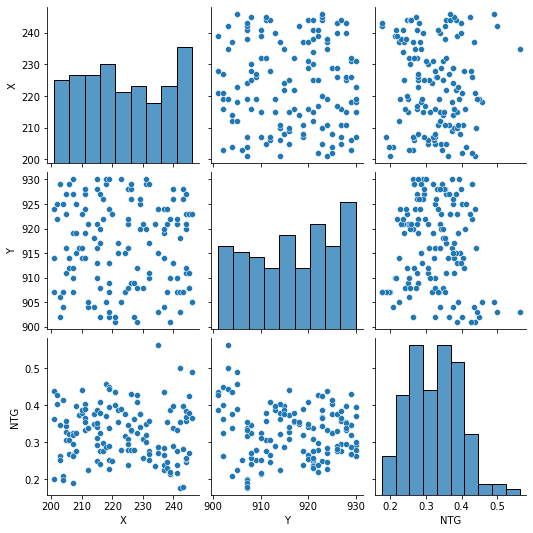

In [16]:
sns.pairplot(train)

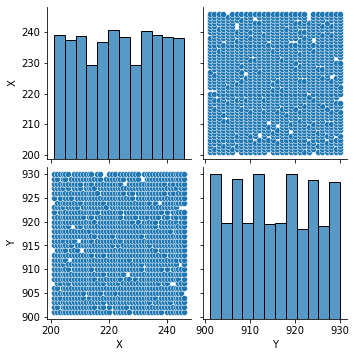

In [17]:
sns.pairplot(test_clear)

Не забудем рассмотреть описательную статистику:

In [18]:
train.describe()

,X,Y,NTG
count,138.000000,138.000000,138.000000
mean,223.195652,916.630435,0.325720
std,13.590926,8.765456,0.072432
min,201.000000,901.000000,0.177000
25%,211.000000,909.000000,0.270175
50%,222.500000,917.000000,0.325900
75%,236.500000,924.000000,0.377475
max,246.000000,930.000000,0.562500


In [19]:
test_clear.describe()

,X,Y
count,1242.000000,1242.000000
mean,223.533816,915.374396
std,13.250974,8.641061
min,201.000000,901.000000
25%,212.000000,908.000000
50%,224.000000,915.000000
75%,235.000000,923.000000
max,246.000000,930.000000


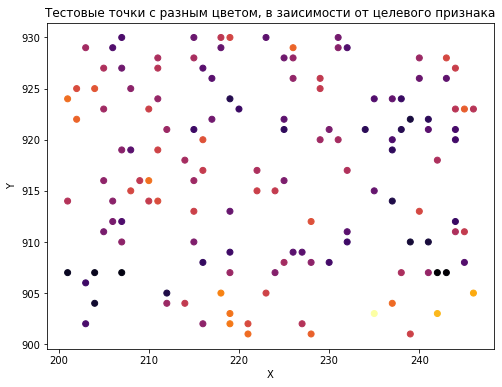

In [118]:
plt.figure(figsize=(8, 6))
plt.scatter(train.X, train.Y, c=train.NTG, cmap='inferno')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Тестовые точки с цветом, зависящим от целевого признака')
None

Для большей наглядности построим трехмерный график плоскости

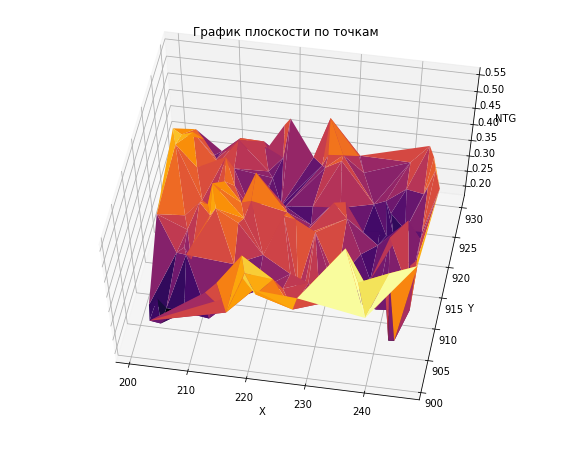

In [119]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(train.X, train.Y, train.NTG, cmap='inferno')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('NTG')
ax.view_init(60, -80)
plt.title('График плоскости по точкам')
None

# Построение моделей

## Градиентный бустинг (CatBoost)

In [ ]:
!pip install catboost
import catboost
from sklearn.model_selection import train_test_split

In [ ]:
X_tt, X_tv, y_tt, y_tv = train_test_split(X_train, y_train, 
                                          test_size=0.2, random_state=0)
eval_dataset = catboost.Pool(X_tv, y_tv)
model = catboost.CatBoostRegressor(n_estimators=100, loss_function='RMSE', 
                                   eval_metric='RMSE', random_seed=0)

params = {
    'learning_rate': [0.001, 0.01, 0.1, 0.5, 0.9],
    'depth': [3, 5, 6, 8, 10]
}

model.grid_search(params, X_tt, y_tt)
None


bestTest = 0.3074640751
bestIteration = 99

0:	loss: 0.3074641	best: 0.3074641 (0)	total: 19ms	remaining: 455ms

bestTest = 0.1515734764
bestIteration = 99

1:	loss: 0.1515735	best: 0.1515735 (1)	total: 30.5ms	remaining: 350ms

bestTest = 0.06229279151
bestIteration = 81

2:	loss: 0.0622928	best: 0.0622928 (2)	total: 42.7ms	remaining: 313ms

bestTest = 0.06229812906
bestIteration = 8

3:	loss: 0.0622981	best: 0.0622928 (2)	total: 56.2ms	remaining: 295ms

bestTest = 0.05740890241
bestIteration = 64

4:	loss: 0.0574089	best: 0.0574089 (4)	total: 70.4ms	remaining: 281ms

bestTest = 0.309658348
bestIteration = 99

5:	loss: 0.3096583	best: 0.0574089 (4)	total: 87.3ms	remaining: 277ms

bestTest = 0.1620049138
bestIteration = 99

6:	loss: 0.1620049	best: 0.0574089 (4)	total: 105ms	remaining: 270ms

bestTest = 0.06289976736
bestIteration = 84

7:	loss: 0.0628998	best: 0.0574089 (4)	total: 122ms	remaining: 260ms

bestTest = 0.06547261993
bestIteration = 25

8:	loss: 0.0654726	best: 0.0574089 (

In [ ]:
model.get_params()

{'depth': 3,
 'eval_metric': 'RMSE',
 'learning_rate': 0.9,
 'loss_function': 'RMSE',
 'n_estimators': 100,
 'random_seed': 0}

In [ ]:
preds = model.predict(test_clear)
preds

array([0.26255026, 0.25701507, 0.30155058, ..., 0.39234468, 0.39086417,
       0.37742631])

Получился результат с RMSE=0.0574 на валидации 

## SVR

In [42]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

svr = SVR(kernel='poly')

params = {
    'C': [1, 10, 50, 100]
}

grid = GridSearchCV(svr, params, scoring='neg_root_mean_squared_error')
grid.fit(X_train, y_train)
preds = grid.predict(test_clear)
print('SVR best RMSE:', -grid.best_score_)

SVR best RMSE: 0.07464776421619676


In [43]:
grid.best_estimator_

SVR(C=1, cache_size=200, coef0=0.0, degree=3, epsilon=0.1, gamma='scale',
    kernel='poly', max_iter=-1, shrinking=True, tol=0.001, verbose=False)

## Nearest Neighbour

In [37]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV

knn = KNeighborsRegressor()

params = {
    'n_neighbors': [1, 3, 5, 7, 9],
    'weights': ['uniform', 'distance']
}

grid = GridSearchCV(knn, params, scoring='neg_root_mean_squared_error')
grid.fit(X_train, y_train)
preds = grid.predict(test_clear)
print('KNN best RMSE:', -grid.best_score_)

KNN best RMSE: 0.07163216021268055


In [41]:
grid.best_estimator_

KNeighborsRegressor(algorithm='auto', leaf_size=30, metric='minkowski',
                    metric_params=None, n_jobs=None, n_neighbors=9, p=2,
                    weights='distance')

## Decision Tree

In [45]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

tree = DecisionTreeRegressor(random_state=0)

params = {
    'criterion': ['mse', 'friedman_mse', 'mae'],
    'splitter': ['best', 'random'],
    'max_depth': [3, 5, 8, 12, None]
}

grid = GridSearchCV(tree, params, scoring='neg_root_mean_squared_error')
grid.fit(X_train, y_train)
preds = grid.predict(test_clear)
print('Decision Tree best RMSE:', -grid.best_score_)

Decision Tree best RMSE: 0.07174702254810592


In [46]:
grid.best_estimator_

DecisionTreeRegressor(ccp_alpha=0.0, criterion='mse', max_depth=3,
                      max_features=None, max_leaf_nodes=None,
                      min_impurity_decrease=0.0, min_impurity_split=None,
                      min_samples_leaf=1, min_samples_split=2,
                      min_weight_fraction_leaf=0.0, presort='deprecated',
                      random_state=0, splitter='random')

## Random Forest

In [53]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(n_estimators=100, random_state=0)

params = {
    'max_depth': [3, 5, 9, 14, None]
}

grid = GridSearchCV(rf, params, scoring='neg_root_mean_squared_error')
grid.fit(X_train, y_train)
preds = grid.predict(test_clear)
print('Random Forest best RMSE:', -grid.best_score_)

Random Forest best RMSE: 0.06862776398330944


In [54]:
grid.best_estimator_

RandomForestRegressor(bootstrap=True, ccp_alpha=0.0, criterion='mse',
                      max_depth=3, max_features='auto', max_leaf_nodes=None,
                      max_samples=None, min_impurity_decrease=0.0,
                      min_impurity_split=None, min_samples_leaf=1,
                      min_samples_split=2, min_weight_fraction_leaf=0.0,
                      n_estimators=100, n_jobs=None, oob_score=False,
                      random_state=0, verbose=0, warm_start=False)

## Интерполяция

В принципе по данным видно, что есть возможность сделать интерполяцию:
1. Тренировочные и тестовые X и Y лежат в одном интервале (макс и мин значения совпадают);
2. Низкая размерность данных, что позволяет наглядно рассмотреть как изменяются целевая переменная, в зависимости от признаков.

In [112]:
from scipy import interpolate
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor

rmse = np.array([])
kf = KFold(n_splits = 3, random_state=0, shuffle=True)
for train_index, valid_index in kf.split(X_train):
    # Find train and valid samples
    X_tt, X_tv = X_train.iloc[train_index], X_train.iloc[valid_index]
    y_tt, y_tv = y_train.iloc[train_index], y_train.iloc[valid_index]
    
    # Set up interpolation available area
    x_min, x_max = np.min(X_tt.X), np.max(X_tt.X)
    y_min, y_max = np.min(X_tt.Y), np.max(X_tt.Y)
    xx = np.arange(x_min, x_max + 1, 1)
    yy = np.arange(y_min, y_max + 1, 1)
    xx, yy = np.meshgrid(xx, yy)

    # Interpolate and save the results
    vals = interpolate.griddata(X_tt, y_tt, (xx.ravel(), yy.ravel()), 
                                method='cubic')
    solve = pd.DataFrame({'X': xx.ravel(), 'Y': yy.ravel(), 'NTG': vals})

    # Prediction
    solve_wona = solve.dropna()
    knn = KNeighborsRegressor(n_neighbors=3, weights='distance')
    knn.fit(solve_wona[['X', 'Y']], solve_wona.NTG)
    preds = np.array([])
    for i, row in X_tv.iterrows():
        pred_row = solve[(solve.X == row.X) & (solve.Y == row.Y)]
        if pred_row.NTG.isna().item():
            # If interpolation couldn't find NTG at this point we will use KNN
            preds = np.append(preds, knn.predict(row.to_numpy().reshape(1, -1)))
        else:
            preds = np.append(preds, pred_row.NTG.item())
    
    rmse = np.append(rmse, np.sqrt(mean_squared_error(y_tv, preds)))

print('RMSE:', np.mean(rmse))

RMSE: 0.06910280434253514


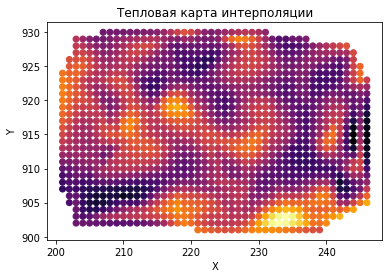

In [115]:
xx = np.arange(np.min(X_train.X), np.max(X_train.X) + 1, 1)
yy = np.arange(np.min(X_train.Y), np.max(X_train.Y) + 1, 1)
xx, yy = np.meshgrid(xx, yy)

vals = interpolate.griddata(train[['X', 'Y']], train.NTG, 
                            (xx.ravel(), yy.ravel()), method='cubic')
solve = pd.DataFrame({'X': xx.ravel(), 'Y': yy.ravel(), 'NTG': vals})

solve_wona = solve.dropna()
knn = KNeighborsRegressor(n_neighbors=3, weights='distance')
knn.fit(solve_wona[['X', 'Y']], solve_wona.NTG)
preds = np.array([])
for i, row in test_clear.iterrows():
    pred_row = solve[(solve.X == row.X) & (solve.Y == row.Y)]
    if pred_row.NTG.isna().item():
        preds = np.append(preds, knn.predict(row.to_numpy().reshape(1, -1)))
    else:
        preds = np.append(preds, pred_row.NTG.item())

plt.scatter(xx.ravel(), yy.ravel(), c=vals, cmap='inferno')
plt.title('Тепловая карта интерполяции')
plt.xlabel('X')
plt.ylabel('Y')
None

## Вывод в файл

In [116]:
test['NTG'] = preds
test.head(10)

,Well,X,Y,NTG
0,201-901,201,901,0.260447
1,201-902,201,902,0.259738
2,201-903,201,903,0.249717
3,201-904,201,904,0.241353
4,201-905,201,905,0.226201
5,201-906,201,906,0.222643
6,201-908,201,908,0.208146
7,201-909,201,909,0.226542
8,201-910,201,910,0.252391
9,201-911,201,911,0.282297


In [ ]:
import pytz
pytz.all_timezones

In [117]:
from datetime import datetime
nsk = pytz.timezone('Asia/Novosibirsk')
now = datetime.now(tz=nsk)
str_now = now.strftime('%d-%m-%Y_%H-%M')
test.to_csv('/content/drive/MyDrive/Colab Notebooks/Hackatons/' 
            + f'Я пофессионал/Полуфинал/prediction_{str_now}.csv', 
            index=False)